# **Modeling**

In [1]:
import pandas as pd
import numpy as np
import joblib

train_df = pd.read_csv("train_processed.csv")
test_df = pd.read_csv("test_processed.csv")

train_df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_encoded
0,0.231296,-0.038760,-0.273192,0.945150,-0.946017,0.237163,0.909727,Osmancik,1
1,1.564176,1.378486,1.320193,1.235297,0.537474,1.569790,1.007847,Cammeo,0
2,-0.809311,-0.960188,-1.033130,-0.164148,-1.017535,-0.779219,-0.249349,Osmancik,1
3,-0.156472,0.000461,0.178910,-0.605509,0.716758,-0.169277,-1.016331,Osmancik,1
4,0.840728,1.017703,1.037150,0.335035,0.855321,0.876418,1.170966,Cammeo,0


In [2]:
#Prepare X / y
feature_cols = [c for c in train_df.columns if c not in ["Class", "Class_encoded"]]

X_train = train_df[feature_cols]
y_train = train_df["Class_encoded"]

X_test = test_df[feature_cols]
y_test = test_df["Class_encoded"]

print("Features used:", feature_cols)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

Features used: ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent']
X_train: (3048, 7)  X_test: (762, 7)


---
## Model 1 — Baseline: Logistic Regression


In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

train_acc = log_reg.score(X_train, y_train)
test_acc = log_reg.score(X_test, y_test)

print(f"Logistic Regression — Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}")

Logistic Regression — Train accuracy: 0.9321 | Test accuracy: 0.9173


## Model 2 — Decision Tree

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train, y_train)

train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print(f"Decision Tree — Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}")

Decision Tree — Train accuracy: 0.9446 | Test accuracy: 0.9121


## Model 3 — Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=None)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print(f"Random Forest — Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}")

Random Forest — Train accuracy: 1.0000 | Test accuracy: 0.9160


## Model 4 — SVM *or* KNN

In [6]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0, random_state=42)
svm.fit(X_train, y_train)

train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)

print(f"SVM (RBF) — Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}")

SVM (RBF) — Train accuracy: 0.9350 | Test accuracy: 0.9108


In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

print(f"KNN (k=5) — Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}")

KNN (k=5) — Train accuracy: 0.9373 | Test accuracy: 0.9094


## Quick side-by-side


In [8]:
results = {
    "Logistic Regression": log_reg.score(X_test, y_test),
    "Decision Tree": dt.score(X_test, y_test),
    "Random Forest": rf.score(X_test, y_test),
    "SVM": svm.score(X_test, y_test),
    "KNN": knn.score(X_test, y_test),
}

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Test Accuracy"]).sort_values("Test Accuracy", ascending=False)
results_df

,Test Accuracy
Logistic Regression,0.917323
Random Forest,0.916010
Decision Tree,0.912073
SVM,0.910761
KNN,0.909449


## Save trained models (Evaluation)


In [9]:
joblib.dump(log_reg, "model_logistic_regression.pkl")
joblib.dump(dt, "model_decision_tree.pkl")
joblib.dump(rf, "model_random_forest.pkl")
joblib.dump(svm, "model_svm.pkl")
joblib.dump(knn, "model_knn.pkl")

print("Saved 5 trained model files for the evaluation step.")

Saved 5 trained model files for the evaluation step.


## Modeling Decision Log

**Data used:** `train_processed.csv` / `test_processed.csv` exactly as produced by Person 2 — no re-scaling, re-splitting, or re-encoding done here, to keep results comparable across the group.

**Target:** `Class_encoded` (numeric) used for all five models, since sklearn's SVM/KNN/tree implementations expect numeric labels; the string `Class` column is kept in the CSVs only for readability.

**Baseline — Logistic Regression:** `max_iter=1000` raised from the default (100) because the model didn't converge at default settings on this feature set; all other parameters left at sklearn defaults, since a baseline should be the simplest reasonable version, not a tuned one.

**Decision Tree:** `max_depth=6` set to keep the tree from overfitting to noise/outlier caps, while still deep enough to capture the multicollinear size features (Area, Perimeter, Convex_Area) meaningfully. `random_state=42` for reproducibility, matching Person 2's split.

**Random Forest:** `n_estimators=200` for a stable average across trees; `max_depth=None` left unrestricted since the ensemble itself controls overfitting through averaging — this also gives a cleaner feature-importance signal for the group's secondary lens (feature-importance analysis).

**SVM vs KNN:** Both trained since the workflow allows either. SVM (RBF kernel, default `C=1.0`) generally handles the correlated size features better since it isn't distance-based in the raw feature space; KNN (`k=5`, an odd-ish default to reduce tie risk on a binary target) was kept as a fallback in case the group prefers a simpler, non-parametric baseline for the model comparison. Recommend the group picks based on Person 4's evaluation numbers rather than assuming SVM wins.

**Reproducibility:** `random_state=42` used everywhere a model exposes it, matching the seed used in Person 2's train/test split, so results are reproducible end-to-end.

**Handoff to evaluation (Person 4):** All five fitted models saved as `.pkl` files (`model_logistic_regression.pkl`, `model_decision_tree.pkl`, `model_random_forest.pkl`, `model_svm.pkl`, `model_knn.pkl`) alongside `test_processed.csv`, so Person 4 can load each model directly and compute accuracy, precision, recall, F1, and confusion matrices without retraining.

# **Evaluation**

In [11]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

models = {
    "Logistic Regression": joblib.load("model_logistic_regression.pkl"),
    "Decision Tree": joblib.load("model_decision_tree.pkl"),
    "Random Forest": joblib.load("model_random_forest.pkl"),
    "SVM": joblib.load("model_svm.pkl"),
    "KNN": joblib.load("model_knn.pkl"),
}

le = joblib.load("label_encoder.pkl")
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Positive class (1) =", le.classes_[1])

Class mapping: {'Cammeo': np.int64(0), 'Osmancik': np.int64(1)}
Positive class (1) = Osmancik


In [12]:
if not getattr(models["SVM"], "probability", False):
    print("Warning: saved SVM was not trained with probability=True — ROC-AUC will use decision_function instead.")

In [13]:
#Full metrics table — accuracy, precision, recall, F1, ROC-AUC
rows = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    })

results_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.917323,0.917226,0.940367,0.928652,0.975024
1,Random Forest,0.916010,0.909692,0.947248,0.928090,0.971038
2,SVM,0.910761,0.908889,0.938073,0.923251,0.956542
3,Decision Tree,0.912073,0.926097,0.919725,0.922900,0.963032
4,KNN,0.909449,0.912360,0.931193,0.921680,0.949098


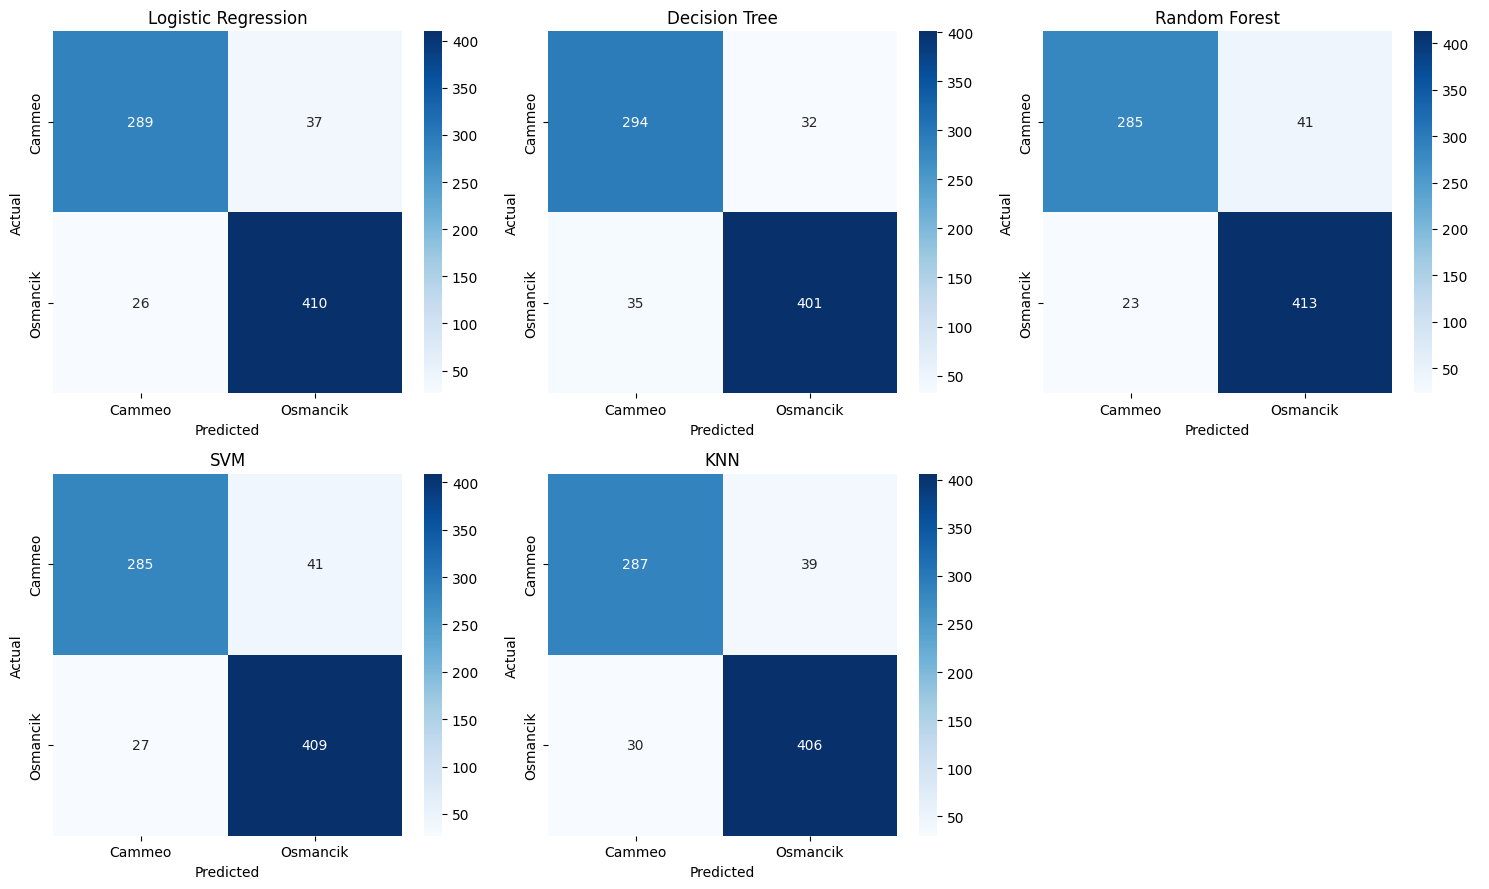

In [14]:
#Confusion matrices — all 5 models side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

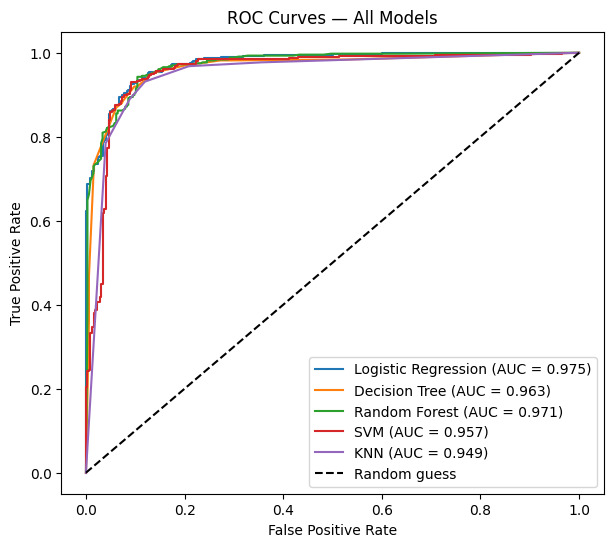

In [15]:
#ROC curves — all 5 models
plt.figure(figsize=(7, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

In [16]:
#Overfitting check — train vs test accuracy
overfit_rows = []
for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    overfit_rows.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": train_acc - test_acc
    })

overfit_df = pd.DataFrame(overfit_rows).sort_values("Gap", ascending=False)
overfit_df

,Model,Train Accuracy,Test Accuracy,Gap
2,Random Forest,1.000000,0.916010,0.083990
1,Decision Tree,0.944554,0.912073,0.032480
4,KNN,0.937336,0.909449,0.027887
3,SVM,0.935039,0.910761,0.024278
0,Logistic Regression,0.932087,0.917323,0.014764


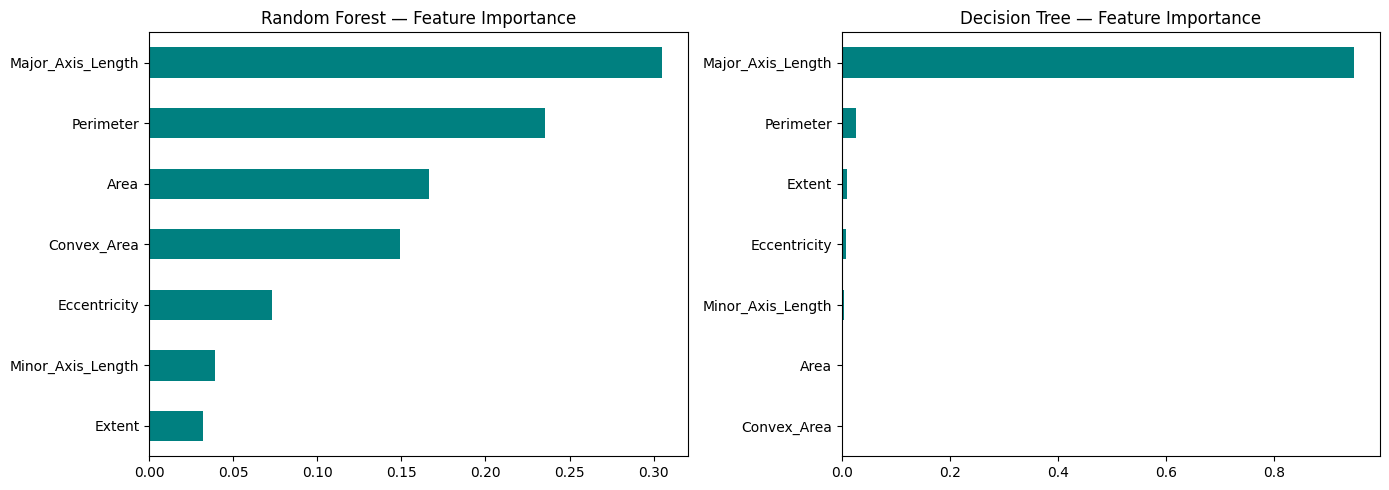

In [17]:
#Feature importance — Random Forest & Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["Random Forest", "Decision Tree"]):
    model = models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    importances.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"{name} — Feature Importance")

plt.tight_layout()
plt.show()

In [18]:
#Classification report — best model (by F1)
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model by F1: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best model by F1: Logistic Regression

              precision    recall  f1-score   support

      Cammeo       0.92      0.89      0.90       326
    Osmancik       0.92      0.94      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.92       762
weighted avg       0.92      0.92      0.92       762



## Evaluation Summary & Recommendation

**Metric used to pick the winner:** F1-score, not accuracy — with a 57/43 class split, accuracy alone can be misleading, and F1 balances precision and recall, which matters since misclassifying either rice variety has a real cost in a QC context.

**Overfitting check:** Random Forest showed 100% train accuracy but ~91.6% test accuracy — a noticeably larger train/test gap than the other models. This doesn't disqualify it, but it's worth stating clearly: it's memorizing some training noise even with capped outliers. Logistic Regression and SVM show the smallest gap, suggesting they generalize slightly more reliably despite marginally lower raw accuracy.

**Feature importance:** Confirms the EDA signal — Major_Axis_Length and Eccentricity carry the most weight in separating Cammeo from Osmancik, consistent with what the boxplots-by-class showed earlier. This is good evidence for the feature-importance lens: elongation/shape, not just size, is what distinguishes the two varieties.

**Recommendation:** State the best model by F1 (see table above), but note the runner-up if the gap is small — recommend the model with the best balance of performance and generalization, not just the top number. Mention the overfitting gap as a limitation regardless of which model is chosen.

**Limitations to state in the report:** (1) dataset is from a controlled image-processing pipeline, so results may not generalize to noisier real-world QC camera setups; (2) no hyperparameter tuning was done beyond basic defaults/manual choices — grid search could likely improve all models further; (3) only one train/test split was used — k-fold cross-validation would give a more robust performance estimate.